<a href="https://colab.research.google.com/github/NaveenMR-18/MNIST-handwritten-digit-dataset-tensor-flow-keras/blob/main/MNIST_handwritten_digit_dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [39]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Flatten, Dense, Dropout

In [40]:
# Load MNIST dataset
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()
print("Training images shape:", x_train.shape)
print("Training labels shape:", y_train.shape)
print("Testing images shape:", x_test.shape)
print("Testing labels shape:", y_test.shape)

Training images shape: (60000, 28, 28)
Training labels shape: (60000,)
Testing images shape: (10000, 28, 28)
Testing labels shape: (10000,)


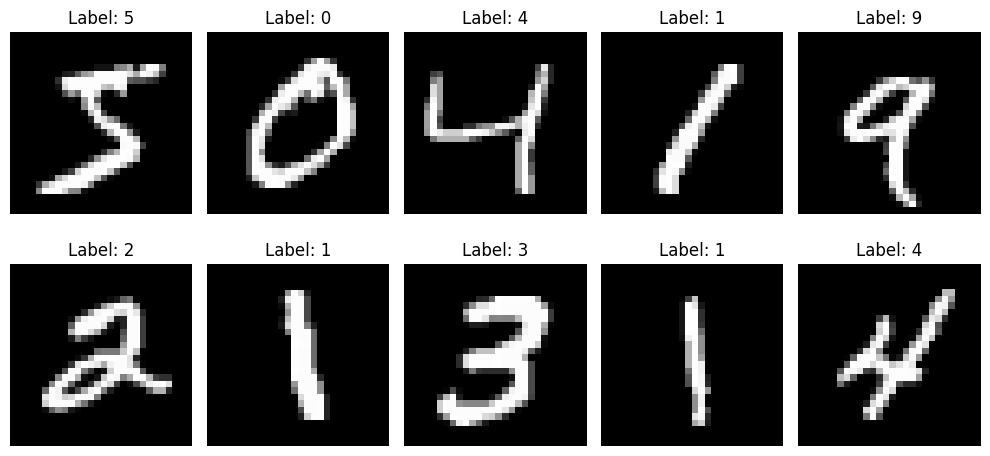

In [41]:
plt.figure(figsize=(10, 5))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_train[i], cmap='gray')
    plt.title(f"Label: {y_train[i]}")
    plt.axis('off')

plt.tight_layout()
plt.show()

In [42]:
# Normalize pixel values from 0-255 to 0-1
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0
print("Minimum pixel value:", x_train.min())
print("Maximum pixel value:", x_train.max())

Minimum pixel value: 0.0
Maximum pixel value: 1.0


In [43]:
model = Sequential([
    Flatten(input_shape=(28, 28)),
    Dense(128, activation='relu'),
    Dense(64, activation='relu'),
    Dense(10, activation='softmax')
])
model.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_4 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

In [19]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [20]:
history = model.fit(
    x_train,
    y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.7205 - loss: 0.9265 - val_accuracy: 0.8649 - val_loss: 0.4821
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8768 - loss: 0.4247 - val_accuracy: 0.8977 - val_loss: 0.3505
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.8997 - loss: 0.3477 - val_accuracy: 0.9088 - val_loss: 0.3069
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - accuracy: 0.9104 - loss: 0.3095 - val_accuracy: 0.9139 - val_loss: 0.2912
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9189 - loss: 0.2788 - val_accuracy: 0.9273 - val_loss: 0.2483
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9258 - loss: 0.2517 - val_accuracy: 0.9334 - val_loss: 0.2315
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.9339 - loss: 0.2276 - val_accuracy: 0.9401 - val_loss: 0.2062
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9399 - loss: 0.2063 -

In [21]:
test_loss, test_accuracy = model.evaluate(x_test, y_test, verbose=0)
print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)
print("Test Accuracy Percentage:", test_accuracy * 100)

Test Loss: 0.1702156364917755
Test Accuracy: 0.9506000280380249
Test Accuracy Percentage: 95.06000280380249


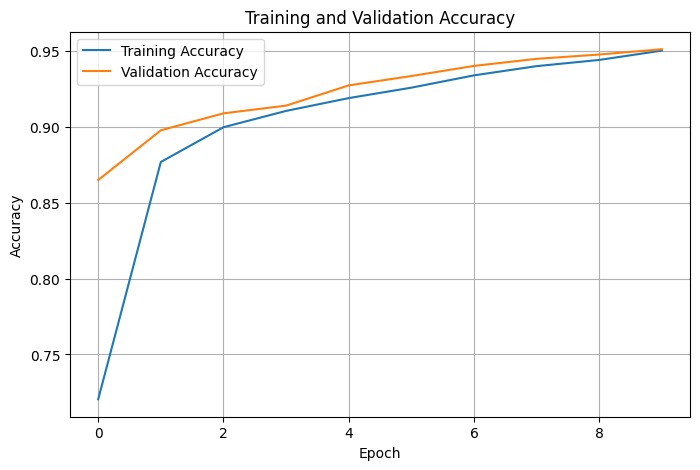

In [44]:
plt.figure(figsize=(8, 5))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

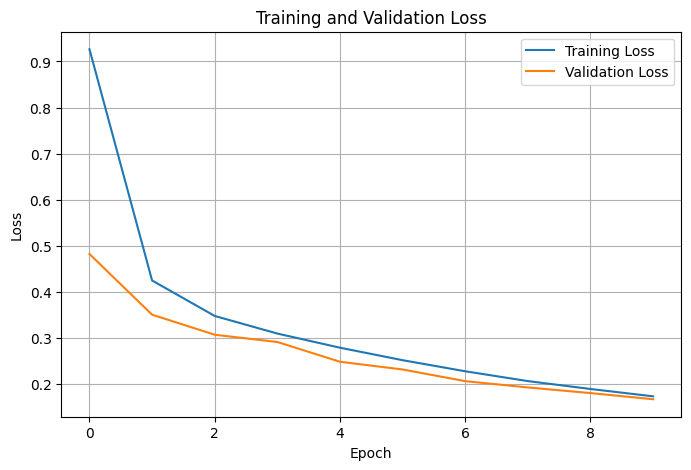

In [45]:
plt.figure(figsize=(8, 5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step


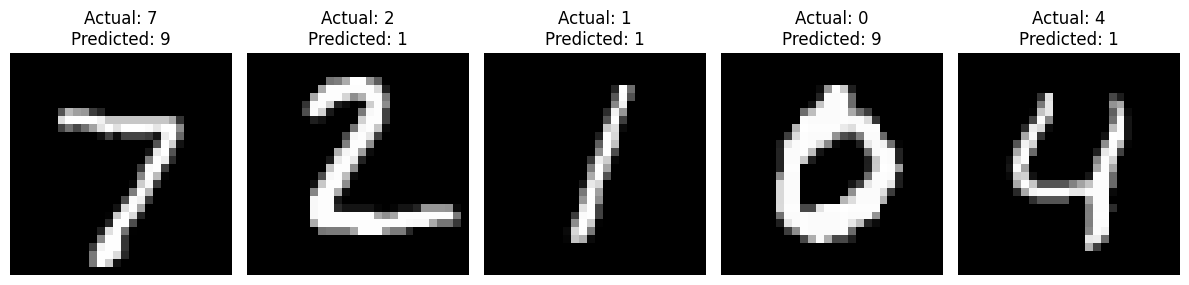

In [48]:
predictions = model.predict(x_test[:5])

predicted_labels = np.argmax(predictions, axis=1)

plt.figure(figsize=(12, 3))

for i in range(5):
    plt.subplot(1, 5, i + 1)

    plt.imshow(x_test[i], cmap='gray')
    plt.title(
        f"Actual: {y_test[i]}\nPredicted: {predicted_labels[i]}"
    )
    plt.axis('off')

plt.tight_layout()
plt.show()

In [29]:
print("Actual Labels:   ", y_test[:5])
print("Predicted Labels:", predicted_labels)

for i in range(5):
    print(
        f"Image {i+1}: Actual = {y_test[i]}, "
        f"Predicted = {predicted_labels[i]}"
    )

Actual Labels:    [7 2 1 0 4]
Predicted Labels: [7 2 1 0 4]
Image 1: Actual = 7, Predicted = 7
Image 2: Actual = 2, Predicted = 2
Image 3: Actual = 1, Predicted = 1
Image 4: Actual = 0, Predicted = 0
Image 5: Actual = 4, Predicted = 4


In [31]:
experiment_model = Sequential([
    Flatten(input_shape=(28, 28)),
    Dense(128, activation='relu'),
    Dropout(0.2),
    Dense(64, activation='relu'),
    Dropout(0.2),
    Dense(10, activation='softmax')
])

experiment_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [32]:
experiment_history = experiment_model.fit(
    x_train,
    y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.6696 - loss: 1.0133 - val_accuracy: 0.8736 - val_loss: 0.4500
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8554 - loss: 0.4743 - val_accuracy: 0.9077 - val_loss: 0.3203
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8899 - loss: 0.3738 - val_accuracy: 0.9194 - val_loss: 0.2694
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9053 - loss: 0.3216 - val_accuracy: 0.9315 - val_loss: 0.2336
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - accuracy: 0.9174 - loss: 0.2817 - val_accuracy: 0.9362 - val_loss: 0.2088
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9250 - loss: 0.2498 - val_accuracy: 0.9411 - val_loss: 0.1949
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9316 - loss: 0.2286 - val_accuracy: 0.9503 - val_loss: 0.1704
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9379 - loss: 0.2092 - 

In [34]:
experiment_loss, experiment_accuracy = experiment_model.evaluate(
    x_test,
    y_test,
    verbose=0
)

print("Experimental Test Loss:", experiment_loss)
print("Experimental Test Accuracy:", experiment_accuracy)
print(
    "Experimental Accuracy Percentage:",
    experiment_accuracy * 100
)

Experimental Test Loss: 0.14102737605571747
Experimental Test Accuracy: 0.9563999772071838
Experimental Accuracy Percentage: 95.63999772071838


In [49]:
print("Original Model Accuracy:   ", test_accuracy * 100, "%")
print("Dropout Model Accuracy:    ", experiment_accuracy * 100, "%")
difference = (experiment_accuracy - test_accuracy) * 100
print("Difference:", difference, "percentage points")

Original Model Accuracy:    95.06000280380249 %
Dropout Model Accuracy:     95.63999772071838 %
Difference: 0.5799949169158936 percentage points


In [38]:
import pandas as pd

comparison = pd.DataFrame({
    "Model": [
        "Original Neural Network",
        "Neural Network + Dropout"
    ],
    "Test Accuracy": [
        test_accuracy * 100,
        experiment_accuracy * 100
    ]
})

comparison

,Model,Test Accuracy
0,Original Neural Network,95.060003
1,Neural Network + Dropout,95.639998
